# Algorithmic trading project

Here, I closely follow the first section of the machine learning and quant strategy course https://www.youtube.com/watch?v=9Y3yaoi9rUQ adapting where necessary. The project layout is as follows:
1. Download S&P 500 historical stock price data.
2. Calculate various technical indicators for each stock and aggregate on a monthly level.
3. Filter for the top 150 most liquid stocks.
4. Download Fama-French factors and calculate rolling factor betas for each stock.
5. Fit a $k$-means clustering model to group assets based on their features.
6. For each month, select assets based on the cluster and form a tangency portfolio.
7. Visualise the portfolio returns and compare to SPY (S&P 500 ETF).

In [1]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta as ta
import warnings
import sys

from sklearn.cluster import KMeans
from sklearn.utils import resample

from pandas.tseries.offsets import BDay
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

warnings.filterwarnings('ignore')

In [2]:
sp500 = pd.read_html(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    storage_options={"User-Agent": "Mozilla/5.0"},
    match="Symbol"
)[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)
symbols_list    = sp500['Symbol'].unique().tolist()

end_date   = '2025-08-31'
start_date = pd.to_datetime(end_date) - pd.DateOffset(years=8)

raw = yf.download(tickers=symbols_list, start=start_date, end=end_date, auto_adjust=False,
    actions=True,  group_by="column", threads=True, progress=False)

# stack tickers into the index and change column names
df = raw.stack()
df.index.names = ['date', 'ticker']
df.columns = [c.lower().replace(' ', '_') for c in df.columns]  # e.g., 'Adj Close' -> 'adj_close'

# split-only back-adjustment factor from 'stock_splits'
# yfinance puts split ratio (e.g., 2.0 for 2-for-1, 0.5 for 1-for-2) on the split date
def split_adjust_factor(ratio):
    r = ratio.fillna(1.0).replace(0, 1.0)
    cum_future = r.iloc[::-1].cumprod().shift(1, fill_value=1.0).iloc[::-1]
    return 1.0 / cum_future    # = 1 on/after split day; <1 before                      
    # => adjusts prior days only

# Apply per ticker
df['split_adj'] = (df['stock_splits']
                   .groupby('ticker', group_keys=False)
                   .apply(split_adjust_factor))

# Split-adjust OHLC for range/vol estimators
for col in ['open','high','low','close']:
    df[f'{col}_s'] = df[col] * df['split_adj']

## List of technical indicators and features

With unsupervised learning, we will be clustering assets based on relevant technical indicators and features. The list is below:
- Volatility of the stocks (Rogers-Satchell, or alternatively, Garman-Klass).
- Momentum indicators:
    1. Average true range (ATR).
    2. Relative strength index (RSI).
    3. Bollinger Bands: percent b and bandwidth.
    4. Moving average convergence/divergence (MACD).
- Returns with month duration of 1, 2, 3, 6, and 12, and also include the twelve minus one (12-1) return.

These features will be calculated daily, but resampled on a monthly basis. Furthermore, so as not to bias any individual feature, we will normalise the features by calculating the rolling $z$-scores with a 2 year window (with a minimum of 1 year of data).

A couple of small notes: 
1. We calculate features daily/monthly up until the day we are interested to avoid look-ahead bias.
2. For momentum indicators, we use standard rolling window lengths.

In [3]:
# Typical value for rolling windows days
WINDOW_1 = 14
WINDOW_2 = 20

# Rogers–Satchell Volatility
o, h, l, c = df["open_s"], df["high_s"], df["low_s"], df["close_s"]

log = np.log
df["rs_var"] = log(h / o) * log(h / c) + log(l / o) * log(l / c)

# Garman-Klass Volatility
# df["gk_vol"] = 0.5 * (log(h / l))**2 - (2 * log(2) - 1) * (log(c / o))**2

# ATR using split-adjusted OHLC
tr1 = (h - l)
tr2 = (c.groupby("ticker").shift(1) - h).abs()
tr3 = (c.groupby("ticker").shift(1) - l).abs()
true_range = np.nanmax(np.vstack( [tr1.values, tr2.values, tr3.values] ), axis=0)
df["atr"] = pd.Series(true_range, index=df.index).groupby("ticker").rolling(WINDOW_1).mean().reset_index(level=0, drop=True)

# Compute RSI and normalised
df['rsi'] = df.groupby("ticker")['adj_close'].transform(lambda x: ta.rsi(close=x, length=WINDOW_1))

# Compute Bollinger Bands on total-return close, with 2 std deviation
# %b is BBP, bandwidth is BBB (dimensionless width of bands)
bbp = (df.groupby("ticker")["adj_close"]
         .transform(lambda s: ta.bbands(s, length=WINDOW_2, std=2.0)["BBP_20_2.0_2.0"]))
bbw = (df.groupby("ticker")["adj_close"]
         .transform(lambda s: ta.bbands(s, length=WINDOW_2, std=2.0)["BBB_20_2.0_2.0"]))
df["bb_pctb"], df["bb_bandwidth"] = bbp, bbw

# compute MACD with typical windows
fast, slow, signal = 12, 26, 9

df["macd"] = (df.groupby("ticker")["adj_close"]
      .transform(lambda s: ta.macd(s, fast=fast, slow=slow, signal=signal)[f"MACD_{fast}_{slow}_{signal}"]))

### Filter based on top 150 most liquid stocks

Here, we only take the top 150 most liquid stocks. With the remaining stocks, we will aggregate the daily calculated features on a monthly basis.

In [4]:
# depending on the feature, we either take the mean or the last element in a given month

# quick function so I don't need to copy-paste
def monthly_features(df, last_cols=None, mean_cols=None):
    dfM = df.groupby("ticker").resample("M", level="date")
    parts = []
    if last_cols:
        lastcol = dfM[last_cols].last()
        lastcol.columns = [f"{col}_m" for col in lastcol.columns]
        parts.append(lastcol)
    if mean_cols:
        meancol = dfM[mean_cols].mean()
        meancol.columns = [f"{col}_m" for col in meancol.columns]
        parts.append(meancol)
    out = pd.concat(parts, axis=1).sort_index()
    return out

# dollar-volume scaled for easy visuals
df["dollar_volume"] = (df["close"] * df["volume"]) / 1e6

# features to resample last or mean
LAST_COLS = ["atr", "rsi", "bb_pctb", "macd"]
MEAN_COLS = ["bb_bandwidth", "dollar_volume"]

# build monthly matrix from daily df
dfM = monthly_features(df, LAST_COLS, MEAN_COLS)
dfM.index = dfM.index.set_names(["ticker", "date"])

# resample monthly vol with correct index names
gM = df.groupby("ticker").resample("M", level="date")
rs_vol_m = gM["rs_var"].sum().pow(0.5).rename("rs_vol_m")

# Make index names match m
rs_vol_m.index = rs_vol_m.index.set_names(["ticker", "date"])
dfM["rs_vol_m"] = rs_vol_m.reindex(dfM.index)

# --------------------------------------------------------------------------- #

# monthly total-return close (from daily adj_close / close_tr)
close_m = (
    df.groupby("ticker")["adj_close"]
      .resample("M", level="date").last()
      .rename("close_m")
)
close_m.index = close_m.index.set_names(["ticker","date"])

# Monthly log returns
r1 = close_m.groupby(level=0, group_keys=False).apply(lambda s: np.log(s) - np.log(s.shift(1))).rename("ret_1_m")
# Rolling sums of monthly log returns
r2  = r1.groupby(level=0).rolling(2).sum().reset_index(level=0, drop=True).rename("ret_2_m")
r3  = r1.groupby(level=0).rolling(3).sum().reset_index(level=0, drop=True).rename("ret_3_m")
r6  = r1.groupby(level=0).rolling(6).sum().reset_index(level=0, drop=True).rename("ret_6_m")
r12 = r1.groupby(level=0).rolling(12).sum().reset_index(level=0, drop=True).rename("ret_12_m")

# 12-1 momentum (exclude most recent month)
r12_1 = (r12 - r1).rename("ret_12_1_m")

# join monthly feature matrix
rets = pd.concat([r1, r2, r3, r6, r12, r12_1], axis=1)
dfM = dfM.join(rets)

# --------------------------------------------------------------------------- #

# rolling z-scores on the monthly features
Z_ROLLING_WINDOW = 24  # 2 years
MINP = 12   # minimum of 1 year

g_m = dfM.groupby("ticker")
# exclude dollar_volume_m from z-scoring
cols_for_z = [c for c in dfM.columns if c.endswith("_m") and c != "dollar_volume_m"]

# shifted 1 month to prevent look-ahead
mu = g_m[cols_for_z].transform(lambda s: s.rolling(Z_ROLLING_WINDOW, min_periods=MINP).mean()).shift(1)
sd = g_m[cols_for_z].transform(lambda s: s.rolling(Z_ROLLING_WINDOW, min_periods=MINP).std(ddof=0)).shift(1)
sd = sd.replace(0, np.nan)  # avoid div-by-zero

z = ((dfM[cols_for_z] - mu) / sd).add_suffix("_z")
dfM = dfM.join(z)

# --------------------------------------------------------------------------- #

# dollar-volume filter
# 3y = 36 months; use min_periods to avoid discarding newer tickers
ROLL  = 36
TOP_N = 150

# trailing 3y average dollar volume
dv3y = (
    dfM["dollar_volume_m"]
    .groupby("ticker")
    .transform(lambda s: s.rolling(ROLL, min_periods=MINP).mean())
    .shift(1)
)

dfM["dollar_volume_3y"] = dv3y

# rank within each month and pick top 150
ranks = dv3y.groupby("date").rank(ascending=False, method="first")
mask_top = ranks <= TOP_N

# build features-only matrix
feature_cols = [c for c in dfM.columns if c.endswith("_m_z")]

# subset to top-150 and keep only features
X = (dfM.loc[mask_top, feature_cols]
       .groupby("date")
       .apply(lambda d: d.fillna(d.median()))
       .droplevel(0))

### Download Fama-French factors and calculate rolling betas

Here, we include the latest Fama-French 5-factors:
1. Market factor (MKT) : the excess return of the market portfolio over the risk-free (RF) rate. 
2. Small Minus Big (SMB): average return on nine small stock portfolios minus the average return of the nine big stock portfolios.
3. High Minus Low (HML): average return on the two value (high book-to-market) portfolios minus the average return on the two growth (low book-to-market) portfolios.
    - Book-to-market = Book value of equity / Market capitalisation.
4. Robust Minus Weak (RMW): average return on the two robust (high) operating profitability portfolios minus the average return on the two weak (low) operating profitability portfolios.
    - Operating profitability ≈ Profits from core operations / Book value of equity.
5. Conservative Minus Aggressive (CMA): average return on the two conservative (low) investment portfolios minus the average return on the two aggressive (high) investment portfolios.
    - Investment at $t$ = (Total Assets at $t - 1 - $ Total Assets at $t - 2$) / Total Assets at $t - 2$

Rolling betas are estimated using the following regression:
$$
R_{i, t} - R_{f, t} = \alpha_{ i } + \beta_{ i, 1 }\, ( \text{MKT} - \text{RF} )_{ t } + \beta_{ i, 2 }\ \text{SMB}_{ t } + \beta_{ i, 3 }\ \text{HML}_{ t } + \beta_{ i, 4 }\ \text{RMW}_{ t } + \beta_{ i, 5 }\ \text{CMA}_{ t } + \varepsilon_{i, t}.
$$
We then offset these betas for no look-ahead.

In [5]:
# convert to percent
ff_data = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2010")[0] / 100.0
ff_data.index = ff_data.index.to_timestamp()
ff_data.index.name = "date"
ff_data = ff_data.resample('M').last()
factor_cols = ["Mkt-RF","SMB","HML","RMW","CMA"]
all_cols    = factor_cols + ["RF"]                 # keep RF only to form ret_ex

# clip outliers
def winsorise_cs(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1 - p)
    return s.clip(lo, hi)

# panel index = (ticker, date); column 'ret_1_m'
r1_simple = (close_m / close_m.groupby("ticker").shift(1) - 1).rename("ret_1_m_s")
panel = r1_simple.to_frame().dropna()
panel = panel.join(ff_data[all_cols], on="date")
panel["ret_1_m_s_w"] = panel["ret_1_m_s"].groupby("date").transform(winsorise_cs, p=0.01)
panel["ret_ex"] = panel["ret_1_m_s_w"] - panel["RF"]

K = len(factor_cols)
def _rolling_betas(g):
    des_Mat = sm.add_constant(g[factor_cols])
    res = RollingOLS(
        endog=g["ret_ex"],
        exog=des_Mat,
        window=min(ROLL, len(g)),
        min_nobs=K + 1,                    # const + 5 factors
    ).fit()
    bet = res.params.drop(columns="const", errors="ignore")
    return bet.reindex(g.index)

# run rolling time-series regressions per ticker
betas = panel.groupby(level="ticker", group_keys=False).apply(_rolling_betas)

# lag one month to only use information available at t
betas = betas.groupby(level="ticker").shift(1)
# allow up to 3 months carry if a month is missing
betas = betas.groupby(level="ticker").ffill(limit=3)

# z-score per ticker, using only past info
g  = betas.groupby(level="ticker")
mu = g.transform(lambda s: s.rolling(Z_ROLLING_WINDOW, min_periods=MINP).mean()).shift(1)
sd = g.transform(lambda s: s.rolling(Z_ROLLING_WINDOW, min_periods=MINP).std(ddof=0)).shift(1).replace(0, np.nan)
betas = ((betas - mu) / sd).add_suffix("_beta_z")

# merge to features
X = X.reset_index()
X = X.set_index(["ticker","date"]).sort_index()

# ensure betas has the same kind of index and is sorted
betas = betas.copy()
betas.index = betas.index.set_names(["ticker","date"])
betas = betas.sort_index()

# now join
X = X.join(betas, how="left", validate="many_to_one").dropna()

# winsorise the features with z-scores higher than 4 or lower than -4
feature_cols = [c for c in X.columns if c.endswith("_z")]
X[feature_cols] = X[feature_cols].clip(-4, 4)

### $k$-means clustering based on the features

We first appropriately determine how many clusters we need for our unsupervised learning. We will perform a grid search from $2$-$7$ clusters and use the first 36 months training (out of max 49 months). In this way we will use 3 metrics:
1. Silhouette score: ranges from - 1 to 1, higher the better. This is a measure of how well each point fits in its own cluster vs other cluster.
2. Calinski-Harabasz (CH) index: uses a global average ratio of total between-cluster spread vs. total within-cluster spread. It is unbounded and higher the better.
3. Davies–Bouldin (DB) index: a worst-neighbor ratio. For each cluster, compare its dispersion to the distance to its closest other centroid, take the max competitor per cluster, then average across clusters. Smaller the better.

We will also standardise cross-sectionally so that the $k$-means algorithm is more stable.

In [6]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

K_GRID = range(2, 7)        # try 2..6
TRAIN_MONTHS = 36           # first 36 months for model selection
N_INIT = 50
RANDOM_STATE = 0

# cross-sectional standardisation per month
def cs_standardise(df):
    mu = df.mean()
    sd = df.std(ddof=0).replace(0, np.nan)
    out = (df - mu) / sd
    return out.fillna(0)

# guard for tiny cross-sections (KMeans needs n_samples >= K)
def safe_kmeans_fit_predict(Xm, k):
    if Xm.shape[0] <= k:
        return None  # too few names for this K
    km = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE, init="k-means++")
    return km.fit_predict(Xm)

# choose training months
months = sorted(X.index.get_level_values("date").unique())
train_months = months[:TRAIN_MONTHS]

# training
rows = []
for t in train_months:
    Xm = (X.xs(t, level="date", drop_level=False)[feature_cols]
            .dropna(axis=0, how="any"))
    if Xm.empty:
        continue

    Xm_cs = cs_standardise(Xm)

    for k in K_GRID:
        labels = safe_kmeans_fit_predict(Xm_cs, k)
        if labels is None:
            rows.append((t, k, np.nan, np.nan, np.nan))
            continue
        try:
            sil = silhouette_score(Xm_cs, labels)
            ch  = calinski_harabasz_score(Xm_cs, labels)
            db  = davies_bouldin_score(Xm_cs, labels)
        except Exception:
            sil, ch, db = np.nan, np.nan, np.nan
        rows.append((t, k, sil, ch, db))

scores = pd.DataFrame(rows, columns=["date", "K", "silhouette", "calinski_harabasz", "davies_bouldin"])

# normalise metrics across K so they’re comparable. invert DB
agg = (scores
       .groupby("K", as_index=False)
       .mean(numeric_only=True)
       .rename(columns={"silhouette":"sil","calinski_harabasz":"ch","davies_bouldin":"db"}))

# z-score each metric across K to combine them
for col in ["sil","ch","db"]:
    mu, sd = agg[col].mean(), agg[col].std(ddof=0)
    agg[col + "_z"] = (agg[col] - mu) / sd if sd not in (0, np.nan) else 0.0

agg["score"] = agg["sil_z"] + agg["ch_z"] - agg["db_z"]   # higher is better

print(agg[["K","sil","ch","db","score"]].sort_values("score", ascending=False))


   K       sil         ch        db     score
0  2  0.199377  41.846512  1.760774  4.030281
4  6  0.142184  24.219479  1.710255 -0.419162
3  5  0.144011  26.287339  1.755395 -0.956073
1  3  0.158462  32.983201  1.846774 -1.134636
2  4  0.147566  28.986895  1.810467 -1.520411


This suggests that 2 clusters provide the best separation. While the silhouette score is around 0.2, *i.e.*, not the strongest separation, others are much worse. Moving on, we will set $k = 2$, and cluster our stocks. Using 12-1 (momentum indicator) as the anchor for ordering our clusters.

In [7]:
# anchor for ordering clusters
ANCHOR = "ret_12_1_m_z"

def get_clusters(df, features=feature_cols, anchor=ANCHOR,
                           n_init=N_INIT, random_state=RANDOM_STATE):
    out = df.copy()

    # keep only rows with complete features for KMeans
    Xm = out[features].dropna()

    if Xm.empty or anchor not in Xm.columns or Xm.shape[0] < 2:
        out["cluster"] = np.nan
        return out
    
    # standardise features to avoid scale issues
    Xm_cs = cs_standardise(Xm)

    # fit KMeans on that month’s feature matrix
    km = KMeans(n_clusters=2, n_init=n_init, random_state=random_state, init="k-means++")
    km.fit(Xm_cs.values)  # .values is a plain np array (n_stocks, n_features)

    # find which centroid is low vs high on the anchor feature
    j = Xm.columns.get_loc(anchor)
    order = np.argsort(km.cluster_centers_[:, j])  # low, high
    # map raw labels -> {low:0, high:1}
    labels_ordered = np.where(km.labels_ == order[0], 0, 1)

    # write labels back only to rows clustered
    out.loc[Xm.index, "cluster"] = labels_ordered
    out["cluster"] = out["cluster"].astype("Int8")

    return out

# Run it per month
X = X.groupby("date", group_keys=False).apply(get_clusters)

In [8]:
X

atr_m_z   rsi_m_z  bb_pctb_m_z  macd_m_z  \
ticker date                                                    
AAPL   2021-09-30  0.382498 -1.511725    -1.411523 -1.303316   
       2021-10-31  0.158351  0.095915     0.481473  0.100423   
       2021-11-30  0.778311  1.133757     1.156504  1.169635   
       2021-12-31  1.047781  0.398622     0.169744  1.510641   
       2022-01-31  1.572977  0.280662     0.272102 -1.166981   
...                     ...       ...          ...       ...   
ZTS    2024-09-30 -0.139812  1.065094     0.956299  0.819272   
       2024-10-31  0.078910 -1.532864    -2.113437 -1.015418   
       2024-11-30 -0.488142 -0.712066    -0.411027 -0.765616   
       2024-12-31 -0.481380 -1.642366    -1.313731 -1.402219   
       2025-01-31  0.024468  0.339059     1.166298  0.159738   

                   bb_bandwidth_m_z  rs_vol_m_z  ret_1_m_z  ret_2_m_z  \
ticker date                                                             
AAPL   2021-09-30         -0.819737   -0.532291  -1.343475  -0.873065   
       2021-10-31         -0.842540   -0.660029   0.199016  -0.722075   
       2021-11-30         -0.876409   -0.483534   0.711935   0.592144   
       2021-12-31          0.399818    0.100494   0.375488   0.710178   
       2022-01-31         -0.524446    0.215736  -0.604785  -0.148170   
...                             ...         ...        ...        ...   
ZTS    2024-09-30         -1.038364   -0.313173   0.766236   0.691829   
       2024-10-31         -1.474242   -0.793611  -1.372392  -0.441046   
       2024-11-30         -0.127654    0.161029  -0.373334  -1.291741   
       2024-12-31         -1.179626    0.247799  -1.058234  -1.057791   
       2025-01-31         -0.404309   -0.007836   0.603469  -0.324986   

                   ret_3_m_z  ret_6_m_z  ret_12_m_z  ret_12_1_m_z  \
ticker date                                                         
AAPL   2021-09-30  -0.633462  -0.625107   -1.473615     -0.855538   
       2021-10-31  -0.641836  -0.714115   -1.011335     -1.094649   
       2021-11-30  -0.227270   0.193748   -1.075125     -1.467263   
       2021-12-31   0.740875   0.098023   -1.248297     -1.447670   
       2022-01-31   0.281077  -0.341098   -1.203491     -0.895264   
...                      ...        ...         ...           ...   
ZTS    2024-09-30   0.980108   1.312671    0.829390      0.533510   
       2024-10-31  -0.217110   0.985059    0.833938      1.338528   
       2024-11-30  -0.681045   0.084971   -0.016138      0.137063   
       2024-12-31  -1.955439  -0.962871   -1.274072     -0.743746   
       2025-01-31  -0.543687  -0.958396   -0.947720     -1.192977   

                   Mkt-RF_beta_z  SMB_beta_z  HML_beta_z  RMW_beta_z  \
ticker date                                                            
AAPL   2021-09-30       1.275055   -1.963145   -0.310473   -1.285296   
       2021-10-31       1.227975   -2.172138    0.086530   -1.450877   
       2021-11-30       0.888830   -0.666982   -0.760667   -1.000012   
       2021-12-31       1.017988   -1.449975   -0.238737   -1.030879   
       2022-01-31       0.778263   -1.337084   -0.066104   -1.099818   
...                          ...         ...         ...         ...   
ZTS    2024-09-30       1.183031    1.253764   -1.903159   -2.185385   
       2024-10-31       1.190638    1.191019   -2.336903   -1.851890   
       2024-11-30       0.717612    1.370938   -2.679552   -1.262993   
       2024-12-31       0.347603    1.063011   -2.332664   -0.636652   
       2025-01-31       0.172105    0.880236   -1.510484   -1.759105   

                   CMA_beta_z  cluster  
ticker date                             
AAPL   2021-09-30    1.312865        0  
       2021-10-31    1.340169        0  
       2021-11-30    1.107266        1  
       2021-12-31    1.401322        1  
       2022-01-31    1.011691        1  
...                       ...      ...  
ZTS    2024-09-30    1.693778        1  
       2024-10-31    1.744768    

### Construct portfolio based on the clustering

With the momentum based clustering, we will consider long only positions and form a tangency portfolio, that is, portfolio that maximises the Sharpe ratio for a given level of risk. For diversification purposes we will set an upper and lower weights bound for the portfolio. This optimisation will be performed at the first business day of each month. Therefore, the portfolio will be rebalanced monthly. For simplicity, we neglect the rebalancing costs.

In [9]:
# need portfolio for each start of month in X cluster 1
pf_data = X[X["cluster"] == 1].copy()

pf_data = pf_data.reset_index()
pf_data["trade_date"] = pf_data["date"] + BDay(1)

universe = ( pf_data.groupby("trade_date")["ticker"]
             .apply(list)
             .to_dict() )

pf_data = pf_data.set_index(["date", "ticker"])

# get adj closes for each stock in pf
prices_all = raw['Adj Close']
prices_all = prices_all.sort_index().ffill()              # fill small gaps, keep NaNs at starts
prices_all = prices_all.loc[:, prices_all.notna().any()]  # drop tickers entirely NaN

# FF data already in decimals and monthly
ff = ff_data.copy()
ff.index = ff.index.to_period('M').to_timestamp(how='end')  # month-end alignment
rf_m = ff['RF']  # monthly RF in decimal

# rolling 12m geometric annualised RF (known at month t = uses months t-11..t)
rf_ann = (1.0 + rf_m).rolling(12, min_periods=6).apply(np.prod, raw=True) - 1.0
rf_ann = rf_ann.rename('rf_ann')

# optimiser
def optimise_weights(prices, lb=0.0, ub=0.10, rf=0.0, shrink=True):
    # prices: wide price matrix for the *training window only*
    mu  = expected_returns.mean_historical_return(prices=prices, frequency=252)
    cov = (risk_models.CovarianceShrinkage(prices).ledoit_wolf() if shrink
           else risk_models.sample_cov(prices, frequency=252))
    ef = EfficientFrontier(mu, cov, weight_bounds=(lb, ub))
    ef.max_sharpe(risk_free_rate=rf)   # set rf explicitly
    w = ef.clean_weights()             # small weights -> 0 for nicer output
    return w
    
pf_stock_list = X.index.get_level_values("ticker").unique().tolist()

# optimisation specs
lookback_days = 252          # ~1Y daily lookback
min_obs_frac  = 0.8          # require at least 80% of lookback for each name
ub = 0.10                    # 10% cap per name
min_n_assets = int(np.ceil(1 / ub))  # feasibility: need at least this many names

weights_list = []
for dt in sorted(universe.keys()):
    month_end = pd.Timestamp(dt).to_period('M').to_timestamp(how='end')
    rf_dt = float(rf_ann.get(month_end, 0.0))  # fallback 0.0 if early window lacks 12m

    tickers = sorted(set(universe[dt]))
    tickers = [t for t in tickers if t in prices_all.columns]  # intersect with available prices
    if not tickers:
        continue

    # training window: strictly prior to dt
    train = prices_all.loc[: dt - BDay(1), tickers].last(f"{lookback_days}B")

    # drop names without enough history in the window
    min_obs = int(min_obs_frac * len(train))
    good = [c for c in train.columns if train[c].count() >= min_obs]
    train = train[good].ffill().dropna()

    # check if any left
    if train.shape[1] == 0:
        continue

    N  = train.shape[1]
    lb = 0.5 / N            # ~50% minimum investment for diversification

    # ensure feasibility; if infeasible, relax to equal-weight
    if (N < min_n_assets) or (N * ub < 1.0) or (N * lb > 1.0):
        w = {c: 1.0 / N for c in train.columns}
    else:
        w = optimise_weights(train, lb=lb, ub=ub, rf=rf_dt, shrink=True)

    weights_list.append(pd.Series(w, name=dt))

weights = pd.DataFrame(weights_list).fillna(0.0)  # index=trade_date, columns=tickers

In [10]:
weights.head()

,ADI,ADP,AXP,BA,BAC,BKNG,BSX,C,CCL,COP,...,PGR,DASH,CDNS,ABNB,APP,COIN,FSLR,MCK,VST,HOOD
2021-10-01,0.00943,0.00943,0.00943,0.00943,0.00943,0.00943,0.00943,0.00943,0.00943,0.00943,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-11-01,0.00658,0.00658,0.00658,0.00000,0.00658,0.00658,0.00000,0.00000,0.00000,0.00658,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-12-01,0.00820,0.00820,0.00000,0.00000,0.03329,0.00000,0.00000,0.00000,0.00000,0.00820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-03,0.00000,0.02365,0.00000,0.00595,0.00000,0.00595,0.00595,0.00000,0.00595,0.00595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-02-01,0.00000,0.00000,0.00725,0.00725,0.00725,0.00725,0.00725,0.00725,0.00725,0.10000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Backtest

Finally, we will backtest our strategy against with a typical buy and hold S&P 500 ETF (SPY). We also include the equal weights portfolio from the cluster. Note, we will backtest from out of sample dates.

In [11]:
# start backtest after train months
train_end_month = months[TRAIN_MONTHS - 1]

# first OOS trade
first_oos_trade = (months[TRAIN_MONTHS]).to_period('M').to_timestamp(how='end') + BDay(1)

# Trim weights to OOS only
weights_oos = weights[weights.index >= first_oos_trade]

# date overlap
start_dt = (weights_oos.index.min() - BDay(5))  # small padding before first trade
end_dt   = (weights_oos.index.max() + BDay(5))

# download SPY data
spy = yf.download("SPY", start=start_dt, end=end_dt, auto_adjust=False, progress=False)

spy          = spy["Adj Close"].dropna()
spy_ret      = spy.pct_change().fillna(0.0)
spy_cum      = (1.0 + spy_ret).cumprod()
spy_cum.name = "SPY"

# --------------------------------------------------------------------------- #

# strategy cumulative
ret = prices_all.pct_change()

# Strategy
w_panel  = weights_oos.reindex(ret.index).ffill().fillna(0.0)
w_panel  = w_panel.div(w_panel.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
port_ret = w_panel.mul(ret, fill_value=0.0).sum(axis=1)

# --------------------------------------------------------------------------- #

# OOS dates
oos_dates = set(weights_oos.index)

# equal-weight monthly
ew_w_list = []
for dt, tickers_dt in sorted(universe.items()):
    if dt not in oos_dates:            # keep OOS only
        continue
    tickers_dt = [t for t in tickers_dt if t in prices_all.columns]
    if not tickers_dt:
        continue
    ew_w = pd.Series(1.0/len(tickers_dt), index=tickers_dt, name=dt)
    ew_w_list.append(ew_w)

ew_weights = pd.DataFrame(ew_w_list).fillna(0.0)

# Turn into a daily weight panel (hold until next rebalance)
ew_panel  = ew_weights.reindex(ret.index).ffill().fillna(0.0)
ew_panel  = ew_panel.div(ew_panel.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
ew_ret    = ew_panel.mul(ret, fill_value=0.0).sum(axis=1)

# --------------------------------------------------------------------------- #

# align calendars and compute growth of $1
first_oos = weights_oos.index.min()
idx = spy_ret.index[spy_ret.index >= first_oos] \
        .intersection(port_ret.index).intersection(ew_ret.index)

port_cum = (1.0 + port_ret.loc[idx]).cumprod(); port_cum.name = "Strategy"
ew_cum   = (1.0 + ew_ret.loc[idx]).cumprod();   ew_cum.name   = "Equal-Weight (monthly)"
spy_cum  = (1.0 + spy_ret.loc[idx]).cumprod();  spy_cum.name  = "SPY"

cum_df = pd.concat([port_cum, ew_cum, spy_cum], axis=1)

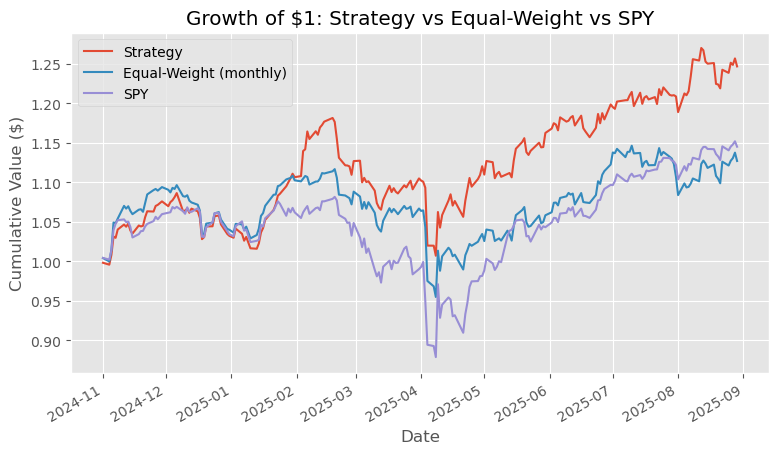

In [12]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(9,5))
cum_df.plot(ax=ax, grid=True)
ax.set_title("Growth of $1: Strategy vs Equal-Weight vs SPY")
ax.set_ylabel("Cumulative Value ($)")
ax.set_xlabel("Date")
# plt.savefig("results/strategy_vs_ew_vs_spy.png", dpi=300, bbox_inches='tight')
plt.show()

Quick performance stats

In [13]:
def perf_stats(r):
    # ensure 1-D series
    if isinstance(r, pd.DataFrame):
        if r.shape[1] != 1:
            raise ValueError("perf_stats expects a 1-D series (one column).")
        r = r.iloc[:, 0]
    else:
        r = pd.Series(r)

    r = r.dropna()
    ann = 252

    mu  = float(r.mean() * ann)
    vol = float(r.std(ddof=0) * np.sqrt(ann))

    sharpe = np.nan if (not np.isfinite(vol) or vol <= 0) else mu / vol

    cum = (1 + r).prod() - 1
    curve = (1 + r).cumprod()
    mdd = (curve / curve.cummax() - 1).min()

    return pd.Series({
        "AnnRet": mu,
        "AnnVol": vol,
        "Sharpe": sharpe,
        "Cumulative": cum,
        "MaxDD": mdd
    })

stats = pd.concat([
    perf_stats(port_ret.loc[idx]),
    perf_stats(ew_ret.loc[idx]),
    perf_stats(spy_ret.loc[idx])
], axis=1)
stats.columns = ["Strategy", "EW", "SPY"]
stats

,Strategy,EW,SPY
AnnRet,0.286026,0.161290,0.187437
AnnVol,0.179586,0.173468,0.209816
Sharpe,1.592693,0.929799,0.893339
Cumulative,0.246650,0.126924,0.144990
MaxDD,-0.147626,-0.144933,-0.187552
